In [2]:
import pandas as pd

# Looking at first 5 rows (default # of rows for `.head()`) of the first file
df = pd.read_parquet("../data/raw/1-Neris-20110810.binetflow.parquet")
df.head()

,dur,proto,dir,state,stos,dtos,tot_pkts,tot_bytes,src_bytes,label,Family
0,1.026539,tcp,->,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT,20110810.binetflow.csv
1,1.009595,tcp,->,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT,20110810.binetflow.csv
2,3.056586,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv
3,3.111769,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv
4,3.083411,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv


### **Label Understanding**

In [6]:
df['label'].value_counts()

label
flow=Background-UDP-Established                                            815604
flow=To-Background-UDP-CVUT-DNS-Server                                     220506
flow=Background-TCP-Established                                            218569
flow=Background-Established-cmpgw-CVUT                                     136333
flow=Background-TCP-Attempt                                                 60097
                                                                            ...  
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-49                                 1
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-60                                 1
flow=From-Botnet-V42-TCP-Established-HTTP-Adobe-4                               1
flow=From-Botnet-V42-TCP-Established-HTTP-Binary-Download-Custom-Port-5         1
flow=From-Botnet-V42-TCP-HTTP-Not-Encrypted-Down-2                              1
Name: count, Length: 113, dtype: int64

In [9]:
df['label'].unique()

['flow=Background-Established-cmpgw-CVUT', 'flow=Background-TCP-Attempt', 'flow=Background-TCP-Established', 'flow=Background-Attempt-cmpgw-CVUT', 'flow=To-Background-CVUT-Proxy', ..., 'flow=From-Botnet-V42-UDP-Attempt-DNS', 'flow=From-Botnet-V42-TCP-Established-HTTP-Ad-52', 'flow=From-Botnet-V42-TCP-Established-HTTP-Ad-49', 'flow=From-Botnet-V42-TCP-Established-HTTP-Ad-34', 'flow=Background-CS-Host-CVUT']
Length: 113
Categories (113, str): ['flow=Background', 'flow=Background-Attempt-cmpgw-CVUT', 'flow=Background-CS-Host-CVUT', 'flow=Background-Established-cmpgw-CVUT', ..., 'flow=To-Background-MatLab-Server', 'flow=To-Background-Stribrek', 'flow=To-Background-UDP-CVUT-DNS-Server', 'flow=To-Normal-V42-UDP-NTP-server']

I.e. There are 113 categories (raw labels). These are descriptions of network traffic context.

In [10]:
df['label_clean'] = df['label'].str.extract(r'flow=([^-]+)')
df['label_clean'].value_counts()

label_clean
Background    1319801
To             243403
From            57960
Normal              9
Name: count, dtype: int64

In [11]:
df['label_clean'].value_counts(normalize=True)

label_clean
Background    0.814103
To            0.150140
From          0.035752
Normal        0.000006
Name: proportion, dtype: float64

The 2 cells above haven't extracted the classes necessary (something like 'Botnet' and 'Background'). 

The following cells will extract botnet and non-botnet classes (binary classification).

In [15]:
df['is_botnet'] = df['label'].str.contains('Botnet').astype(int)
df['is_botnet'].value_counts()

is_botnet
0    1587187
1      33986
Name: count, dtype: int64

Note `0` are those that don't contain 'Botnet', and `1` are those that do.

In [16]:
df['is_botnet'].value_counts(normalize=True)

is_botnet
0    0.979036
1    0.020964
Name: proportion, dtype: float64

It is clear that the data is severely imbalanced, but this seems realistic (most network traffic would be normal/benign, only a small proportion would be malicious).

### **Feature Understanding**

In [ ]:
# Looking at what types of data each label deals with
df.dtypes

dur             float32
proto          category
dir            category
state          category
stos            float32
dtos            float32
tot_pkts          int32
tot_bytes         int64
src_bytes         int64
label          category
Family         category
label_clean      object
is_botnet         int64
dtype: object

In [20]:
df['proto'].value_counts()

proto
udp          1153511
tcp           448832
icmp           13411
rtp             2570
rtcp            2304
arp              443
ipv6-icmp         50
esp               10
ipv6              10
udt               10
ipx/spx            8
pim                7
rarp               4
igmp               2
unas               1
Name: count, dtype: int64

Looking at the categorical classes:

In [21]:
df['dir'].value_counts()

dir
<->    1109168
 ->     502286
<?>       6139
<-        1702
 ?>       1426
who        447
<?           5
Name: count, dtype: int64

In [22]:
df['state'].value_counts()

state
CON          1108492
FSPA_FSPA     215447
S_RA           52222
INT            49410
SRPA_FSPA      35374
              ...   
_FA                1
_FRPA              1
_FSRPA             1
_R                 1
_RA                1
Name: count, Length: 230, dtype: int64

Looking at the numerical classes:

In [ ]:
df[['dur', 'tot_pkts', 'tot_bytes', 'src_bytes']].describe()

,dur,tot_pkts,tot_bytes,src_bytes
count,1.621173e+06,1.621173e+06,1.621173e+06,1.621173e+06
mean,7.506620e+02,4.293056e+01,3.345778e+04,7.174597e+03
std,1.218352e+03,4.124564e+03,4.239958e+06,2.453215e+06
min,0.000000e+00,1.000000e+00,6.000000e+01,0.000000e+00
25%,4.504000e-03,2.000000e+00,2.680000e+02,8.200000e+01
50%,2.021557e+00,4.000000e+00,5.410000e+02,1.860000e+02
75%,1.427422e+03,1.000000e+01,1.520000e+03,7.840000e+02
max,3.600031e+03,2.686731e+06,2.689640e+09,2.635366e+09


In [27]:
df['stos'].value_counts()

stos
0.0      1613162
2.0         1323
3.0          914
1.0          620
192.0          9
Name: count, dtype: int64

In [29]:
df[['stos', 'dtos']].describe()

,stos,dtos
count,1.616028e+06,1.529939e+06
mean,4.787046e-03,7.614683e-04
std,4.626329e-01,4.368807e-02
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00
max,1.920000e+02,3.000000e+00


In [28]:
df['dtos'].value_counts()

dtos
0.0    1529441
2.0        245
3.0        211
1.0         42
Name: count, dtype: int64

array([[<Axes: title={'center': 'dur'}>,
        <Axes: title={'center': 'tot_pkts'}>],
       [<Axes: title={'center': 'tot_bytes'}>,
        <Axes: title={'center': 'src_bytes'}>]], dtype=object)

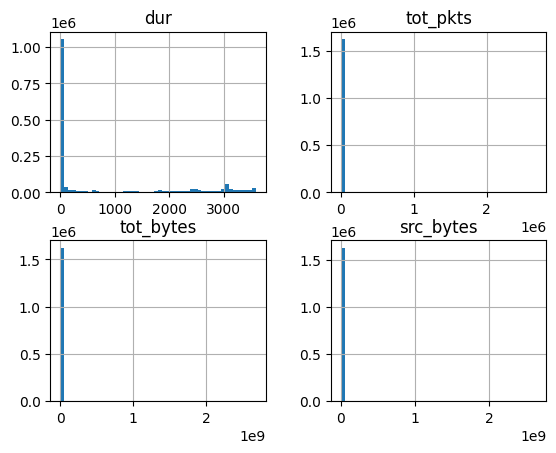

In [24]:
df[['dur', 'tot_pkts', 'tot_bytes', 'src_bytes']].hist(bins=50)

Few things to note from the results above:

1. Numerical features all exhibit a heavy-right skew.
    - Most flows are very small and very short.
    - Very few are extremeley large and dominate the scale.

2. Numerical features `stos` and `dtos` are worth excluding.
    - Heavy skew towards the value 0 for both.
    - Very small variance $10^{-1}$ and $10^{-2}$, compared to the others which are $10^3$ and $10^6$.

3. Categorical features `proto` and `dir` are worth keeping for the baseline features, while `state` is not.
    - `proto` has a moderate number of of unique values (dominated by first 2). 
    - `dir` has a smaller number of unique values (again dominated by first 2).
        - `proto` and `dir` can be one-shot encoded.
    - `state` has 230 unique values, which leaves a long tail of rare categories.

## **First Model**

The goal here is to develop a **clean, interpretable baseline** to then build upon.

**Data:**
```
X = [dur, tot_pkts, tot_bytes, src_bytes, proto, dir]
y = is_botnet
```
(Note, currently learning behaviour from ONE environment: just one .parquet file.)

- Using one-shot encodign on `proto` and `dir`.
- Using a random forest classifier.

In [ ]:
# Checking the columns in the dataframe at the moment to know what to remove for input X
df.head()

,dur,proto,dir,state,stos,dtos,tot_pkts,tot_bytes,src_bytes,label,Family,label_clean,is_botnet
0,1.026539,tcp,->,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT,20110810.binetflow.csv,Background,0
1,1.009595,tcp,->,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT,20110810.binetflow.csv,Background,0
2,3.056586,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv,Background,0
3,3.111769,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv,Background,0
4,3.083411,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv,Background,0


In [30]:
df.drop(columns=['state', 'stos', 'dtos', 'Family', 'label','label_clean'], inplace=True)
df.head()

,dur,proto,dir,tot_pkts,tot_bytes,src_bytes,is_botnet
0,1.026539,tcp,->,4,276,156,0
1,1.009595,tcp,->,4,276,156,0
2,3.056586,tcp,->,3,182,122,0
3,3.111769,tcp,->,3,182,122,0
4,3.083411,tcp,->,3,182,122,0
